In [19]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns 
import matplotlib.pyplot as plt

In [20]:
# load data 
games = pd.read_csv('Data/game_df.csv')

# 1 - Train/test Split

In [21]:
# dropping columns that are not needed for predictive modeling
cols_drop = ['min', 'team_abbreviation_home', 'team_abbreviation_away', 'team_nickname_home', 'team_nickname_away', 
             'team_city_name_home', 'team_city_name_away', 'pts_qtr1_home', 'pts_qtr2_home', 'pts_qtr3_home', 'pts_qtr4_home',
             'pts_ot1_home', 'pts_ot2_home', 'pts_ot3_home', 'pts_ot4_home', 'pts_ot5_home', 'pts_ot6_home', 'pts_ot7_home', 
             'pts_ot8_home', 'pts_ot9_home', 'pts_ot10_home', 'pts_qtr1_away', 'pts_qtr2_away', 'pts_qtr3_away', 'pts_qtr4_away', 
             'pts_ot1_away', 'pts_ot2_away', 'pts_ot3_away', 'pts_ot4_away', 'pts_ot5_away', 'pts_ot6_away', 'pts_ot7_away', 
             'pts_ot8_away', 'pts_ot9_away', 'pts_ot10_away', 'largest_lead_home', 'largest_lead_away', 'lead_changes', 'times_tied', 
             'plus_minus_home', 'plus_minus_away', 'video_available_home', 'video_available_away', 'season_type', 'team_rebounds_home',
             'team_rebounds_away', 'team_turnovers_home', 'total_turnovers_home', 'team_turnovers_away', 'total_turnovers_away', 
             'matchup_home', 'matchup_away', 'game_date', 'team_wins_losses_home', 'team_wins_losses_away']
games2 = games.drop(columns=cols_drop)
games2.columns

Index(['season_id', 'team_id_home', 'team_name_home', 'game_id', 'wl_home',
       'fgm_home', 'fga_home', 'fg_pct_home', 'fg3m_home', 'fg3a_home',
       'fg3_pct_home', 'ftm_home', 'fta_home', 'ft_pct_home', 'oreb_home',
       'dreb_home', 'reb_home', 'ast_home', 'stl_home', 'blk_home', 'tov_home',
       'pf_home', 'pts_home', 'team_id_away', 'team_name_away', 'wl_away',
       'fgm_away', 'fga_away', 'fg_pct_away', 'fg3m_away', 'fg3a_away',
       'fg3_pct_away', 'ftm_away', 'fta_away', 'ft_pct_away', 'oreb_away',
       'dreb_away', 'reb_away', 'ast_away', 'stl_away', 'blk_away', 'tov_away',
       'pf_away', 'pts_away', 'game_date_est', 'game_sequence',
       'team_city_home', 'pts_paint_home', 'pts_2nd_chance_home',
       'pts_fb_home', 'pts_off_to_home', 'team_city_away', 'pts_paint_away',
       'pts_2nd_chance_away', 'pts_fb_away', 'pts_off_to_away'],
      dtype='object')

In [22]:
# change 'wl_home' to be numeric, with W = 1 and L = 0
games2['wl_home'] = games2['wl_home'].map({'W': 1, 'L': 0})

In [23]:
# columns that need to be transformed into rolling averages 
stat_home_cols = ['fgm_home', 'fga_home', 'fg_pct_home', 'fg3m_home', 'fg3a_home', 'fg3_pct_home', 
             'ftm_home', 'fta_home', 'ft_pct_home', 'oreb_home', 'dreb_home', 'reb_home', 
             'ast_home', 'stl_home', 'blk_home', 'tov_home', 'pf_home', 'pts_home',
             'pts_paint_home', 'pts_2nd_chance_home', 'pts_fb_home', 'pts_off_to_home']

stat_away_cols = ['fgm_away', 'fga_away', 'fg_pct_away', 'fg3m_away', 'fg3a_away', 'fg3_pct_away',
             'ftm_away', 'fta_away', 'ft_pct_away', 'oreb_away', 'dreb_away', 'reb_away',
             'ast_away', 'stl_away', 'blk_away', 'tov_away', 'pf_away', 'pts_away', 
             'pts_paint_away', 'pts_2nd_chance_away', 'pts_fb_away', 'pts_off_to_away']

In [24]:
# for each stat column, create a new column that is the rolling average for the last 10 games
# home columns 
for col in stat_home_cols:
    games2[col + '_avg_10'] = games2.groupby('team_id_home')[col].transform(lambda x: x.rolling(10, min_periods=1).mean())
    games2 = games2.drop(columns=[col])

# away columns 
for col in stat_away_cols:
    games2[col + '_avg_10'] = games2.groupby('team_id_away')[col].transform(lambda x: x.rolling(10, min_periods=1).mean())
    games2 = games2.drop(columns=[col])

# verify new columns
games2.columns 

Index(['season_id', 'team_id_home', 'team_name_home', 'game_id', 'wl_home',
       'team_id_away', 'team_name_away', 'wl_away', 'game_date_est',
       'game_sequence', 'team_city_home', 'team_city_away', 'fgm_home_avg_10',
       'fga_home_avg_10', 'fg_pct_home_avg_10', 'fg3m_home_avg_10',
       'fg3a_home_avg_10', 'fg3_pct_home_avg_10', 'ftm_home_avg_10',
       'fta_home_avg_10', 'ft_pct_home_avg_10', 'oreb_home_avg_10',
       'dreb_home_avg_10', 'reb_home_avg_10', 'ast_home_avg_10',
       'stl_home_avg_10', 'blk_home_avg_10', 'tov_home_avg_10',
       'pf_home_avg_10', 'pts_home_avg_10', 'pts_paint_home_avg_10',
       'pts_2nd_chance_home_avg_10', 'pts_fb_home_avg_10',
       'pts_off_to_home_avg_10', 'fgm_away_avg_10', 'fga_away_avg_10',
       'fg_pct_away_avg_10', 'fg3m_away_avg_10', 'fg3a_away_avg_10',
       'fg3_pct_away_avg_10', 'ftm_away_avg_10', 'fta_away_avg_10',
       'ft_pct_away_avg_10', 'oreb_away_avg_10', 'dreb_away_avg_10',
       'reb_away_avg_10', 'ast_away_a

In [25]:
# create new difference df for the stats 
diff_df = games2[['game_id', 'team_id_home', 'team_id_away', 'game_date_est', 'wl_home']].copy() 

# create difference columns for each above stat
diff_df['fgm_dff'] = games2['fgm_home_avg_10'] - games2['fgm_away_avg_10']
diff_df['fga_diff'] = games2['fga_home_avg_10'] - games2['fga_away_avg_10']
diff_df['fg_pct_diff'] = games2['fg_pct_home_avg_10'] - games2['fg_pct_away_avg_10']
diff_df['fg3m_diff'] = games2['fg3m_home_avg_10'] - games2['fg3m_away_avg_10']
diff_df['fg3a_diff'] = games2['fg3a_home_avg_10'] - games2['fg3a_away_avg_10']
diff_df['fg3_pct_diff'] = games2['fg3_pct_home_avg_10'] - games2['fg3_pct_away_avg_10']
diff_df['ftm_diff'] = games2['ftm_home_avg_10'] - games2['ftm_away_avg_10']
diff_df['fta_diff'] = games2['fta_home_avg_10'] - games2['fta_away_avg_10']
diff_df['ft_pct_diff'] = games2['ft_pct_home_avg_10'] - games2['ft_pct_away_avg_10']
diff_df['oreb_diff'] = games2['oreb_home_avg_10'] - games2['oreb_away_avg_10']
diff_df['dreb_diff'] = games2['dreb_home_avg_10'] - games2['dreb_away_avg_10']
diff_df['reb_diff'] = games2['reb_home_avg_10'] - games2['reb_away_avg_10']
diff_df['ast_diff'] = games2['ast_home_avg_10'] - games2['ast_away_avg_10']
diff_df['stl_diff'] = games2['stl_home_avg_10'] - games2['stl_away_avg_10']
diff_df['blk_diff'] = games2['blk_home_avg_10'] - games2['blk_away_avg_10']
diff_df['tov_diff'] = games2['tov_home_avg_10'] - games2['tov_away_avg_10']
diff_df['pf_diff'] = games2['pf_home_avg_10'] - games2['pf_away_avg_10']
diff_df['pts_diff'] = games2['pts_home_avg_10'] - games2['pts_away_avg_10']
diff_df['pts_paint_diff'] = games2['pts_paint_home_avg_10'] - games2['pts_paint_away_avg_10']
diff_df['pts_2nd_chance_diff'] = games2['pts_2nd_chance_home_avg_10'] - games2['pts_2nd_chance_away_avg_10']
diff_df['pts_fb_diff'] = games2['pts_fb_home_avg_10'] - games2['pts_fb_away_avg_10']
diff_df['pts_off_to_diff'] = games2['pts_off_to_home_avg_10'] - games2['pts_off_to_away_avg_10']

diff_df 

,game_id,team_id_home,team_id_away,game_date_est,wl_home,fgm_dff,fga_diff,fg_pct_diff,fg3m_diff,fg3a_diff,...,ast_diff,stl_diff,blk_diff,tov_diff,pf_diff,pts_diff,pts_paint_diff,pts_2nd_chance_diff,pts_fb_diff,pts_off_to_diff
0,29600012,1610612747,1610612756,1996-11-01 00:00:00,1,-1.000000,-28.000000,0.140000,3.000000,5.000000,...,5.000000,-5.0,4.000000,11.000000,1.000000,14.000000,2.000000,8.000000,-11.000000,NaN
1,29600005,1610612748,1610612737,1996-11-01 00:00:00,1,10.000000,13.000000,0.064000,6.000000,5.000000,...,13.000000,-2.0,-3.000000,-5.000000,5.000000,13.000000,0.000000,-6.000000,-8.000000,NaN
2,29600002,1610612751,1610612739,1996-11-01 00:00:00,0,-11.000000,-14.000000,-0.075000,4.000000,8.000000,...,-3.000000,-3.0,6.000000,7.000000,-5.000000,-13.000000,10.000000,-2.000000,2.000000,NaN
3,29600007,1610612765,1610612754,1996-11-01 00:00:00,1,-1.000000,-6.000000,0.025000,0.000000,-1.000000,...,-7.000000,4.0,-1.000000,1.000000,-8.000000,6.000000,4.000000,-3.000000,-3.000000,NaN
4,29600013,1610612744,1610612746,1996-11-01 00:00:00,0,-14.000000,-11.000000,-0.117000,3.000000,10.000000,...,-1.000000,1.0,1.000000,0.000000,-10.000000,-12.000000,10.000000,10.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28256,42200401,1610612743,1610612748,2023-06-01 00:00:00,1,-0.200000,-1.800000,0.005700,-1.600000,-4.300000,...,0.700000,-0.3,0.600000,0.100000,-0.700000,3.500000,0.400000,-1.200000,5.800000,-5.900000
28257,42200402,1610612743,1610612748,2023-06-04 00:00:00,0,0.700000,-2.700000,0.021500,-1.600000,-4.700000,...,0.800000,0.1,0.000000,0.400000,-1.700000,5.300000,3.000000,-0.400000,7.500000,-6.500000
28258,42200403,1610612748,1610612743,2023-06-07 00:00:00,0,-5.000000,-0.400000,-0.055600,2.700000,7.000000,...,-4.000000,1.1,0.200000,-0.500000,-1.000000,-6.800000,-6.800000,1.700000,-1.100000,0.400000
28259,42200404,1610612748,1610612743,2023-06-09 00:00:00,0,-4.500000,-1.200000,-0.046500,1.100000,3.900000,...,-4.300000,0.2,-0.100000,0.700000,-0.100000,-7.300000,-7.000000,0.300000,-1.000000,-1.000000


In [26]:
# creating train and test set, by date, using 75% of dates for training  
train = diff_df[diff_df['game_date_est'] < '2016-01-01']
test = diff_df[diff_df['game_date_est'] >= '2016-01-01']

# creating X as game data and y as win or loss for HOME TEAM
X_train = train.drop(columns=['game_id', 'team_id_home', 'team_id_away', 'game_date_est', 'wl_home']).dropna()
y_train = train.loc[X_train.index, 'wl_home']
X_test = test.drop(columns=['game_id', 'team_id_home', 'team_id_away', 'game_date_est', 'wl_home']).dropna()
y_test = test.loc[X_test.index, 'wl_home']

# verifying that X and y are same shape 
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (17740, 22)
y_train: (17740,)
X_test: (8552, 22)
y_test: (8552,)


# 2 - Model Training

In [ ]:
# scale the data 
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index)

In [28]:
# train logistic regression model and make predictions
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [29]:
# calculate prediction error metrics 
acc = round(accuracy_score(y_test, y_pred), 4)
prec = round(precision_score(y_test, y_pred), 4)
rec = round(recall_score(y_test, y_pred), 4)
f1 = round(f1_score(y_test, y_pred), 4)
auc = round(roc_auc_score(y_test, y_prob), 4)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("ROC AUC:", auc)

Accuracy: 0.7058
Precision: 0.731
Recall: 0.7721
F1 Score: 0.751
ROC AUC: 0.7678


In [30]:
# calculating training and testing accuracy for the model
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Training Accuracy:", round(train_acc, 4))
print("Testing Accuracy:", round(test_acc, 4))

Training Accuracy: 0.7053
Testing Accuracy: 0.6915


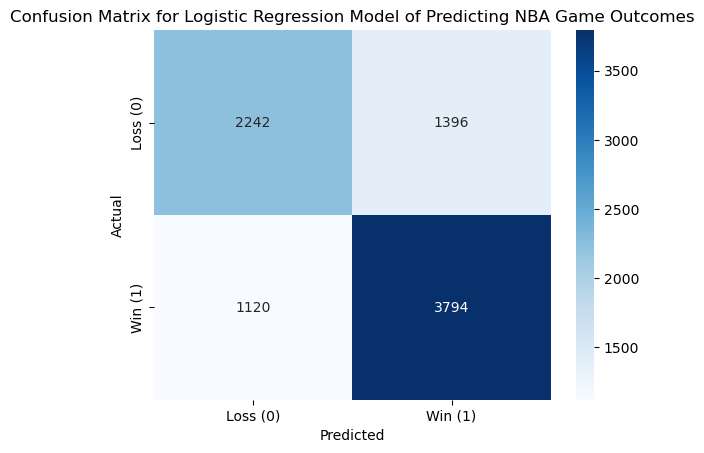

In [31]:
# create correlation matrix and heatmap to show true negatives, true positives, etc 

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loss (0)', 'Win (1)'],
    yticklabels=['Loss (0)', 'Win (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression Model of Predicting NBA Game Outcomes')

plt.show()